# 🫁 Lung Cancer Detection — Explainable Vision Transformer (ViT-B/16)

[![Python](https://img.shields.io/badge/Python-3.9+-blue.svg)](https://python.org)
[![PyTorch](https://img.shields.io/badge/PyTorch-2.x-red.svg)](https://pytorch.org)
[![timm](https://img.shields.io/badge/timm-latest-green.svg)](https://github.com/huggingface/pytorch-image-models)

## 🎯 Objective
**3-class classification** of lung histopathology images:
| Label | Class | Description |
|-------|-------|-------------|
| 0 | `lung_n` | Benign (healthy) lung tissue |
| 1 | `lung_aca` | Lung Adenocarcinoma (most common lung cancer subtype) |
| 2 | `lung_scc` | Lung Squamous Cell Carcinoma |

## 🗺️ Pipeline Overview
| Step | Description |
|------|-------------|
| 0 | GPU Setup |
| 1 | Library Installation |
| 2 | Dataset Mount & Class Verification |
| 3 | Imports & Hyperparameter Configuration |
| 4 | Data Augmentation + Dataset Split |
| 5 | Class-Weighted DataLoaders |
| 6 | ViT-B/16 with 3-class head |
| 7 | Weighted Loss, AdamW, Cosine Scheduler |
| 8 | Training Loop with Checkpointing |
| 9 | Training Curves |
| 10 | Test Evaluation + Per-class Metrics |
| 11 | Confusion Matrix (3×3) |
| 12a | XAI — Attention Rollout |
| 12b | XAI — Grad-CAM for ViT |
| 12c | Side-by-side XAI Comparison |
| 13 | Multi-Modal Fusion Blueprint |
| 14 | Multi-Organ Extension |
| 15 | Save & Download |
| 16 | Single-Image Inference with XAI |

---
> **Dataset**: [LC25000](https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images) — 5,000 images per class.  
> **Key upgrade vs colon notebook**: 3-class head, class-weighted loss, improved Attention Rollout, Grad-CAM, multi-modal blueprint, multi-organ extension.


## ✅ Step 0 — GPU Setup & Verification
> **Required**: Runtime → Change runtime type → T4 GPU → Save


In [7]:
import torch

cuda_available = torch.cuda.is_available()
device = torch.device('cuda' if cuda_available else 'cpu')

print('='*50)
print(f'  CUDA available : {cuda_available}')
if cuda_available:
    print(f'  GPU            : {torch.cuda.get_device_name(0)}')
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  VRAM           : {mem_gb:.1f} GB')
print(f'  Active device  : {device}')
print('='*50)
if not cuda_available:
    print('\n⚠️  No GPU detected. Go to Runtime → Change runtime type → T4 GPU.')


  CUDA available : True
  GPU            : Tesla T4
  VRAM           : 15.6 GB
  Active device  : cuda


## 📦 Step 1 — Library Installation

| Library | Purpose |
|---------|---------|
| `timm` | ViT-B/16 pretrained model |
| `scikit-learn` | Confusion matrix, classification report |
| `matplotlib` / `seaborn` | Plotting |
| `grad-cam` | pytorch-grad-cam (optional fallback for Grad-CAM) |


In [8]:
!pip install -q timm transformers scikit-learn matplotlib seaborn grad-cam
print('✅ All libraries installed.')


✅ All libraries installed.


In [25]:
import os

# 1. Find the actual zip file name (handles that long string of numbers)
zip_files = [f for f in os.listdir('/content/') if f.endswith('.zip')]

if not zip_files:
    print("❌ No zip file found yet. Is the upload finished?")
else:
    # Pick the first zip file found
    target_zip = os.path.join('/content/', zip_files[0])
    print(f"📦 Found: {target_zip}")

    # 2. Create the target directory
    !mkdir -p /content/lung_data

    # 3. Unzip
    print(f"⏳ Extracting {target_zip}...")
    !unzip -q "{target_zip}" -d /content/lung_data

    # 4. Final check
    contents = os.listdir('/content/lung_data')
    print(f"✅ Extraction complete. Folders found: {contents}")

    # Update this for the rest of your script
    DATA_DIR = '/content/lung_data'

📦 Found: /content/dataset2-20260513T203845Z-3-001.zip
⏳ Extracting /content/dataset2-20260513T203845Z-3-001.zip...
[/content/dataset2-20260513T203845Z-3-001.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/dataset2-20260513T203845Z-3-001.zip or
        /content/dataset2-20260513T203845Z-3-001.zip.zip, and cannot find /content/dataset2-20260513T203845Z-3-001.zip.ZIP, period.
✅ Extraction complete. Folders found: []


## 📁 Step 2 — Mount Google Drive & Verify Dataset

### Expected folder structure:
```
lung_dataset/
├── lung_n/            ← Benign tissue      (5,000 images)
├── lung_aca/          ← Adenocarcinoma     (5,000 images)
└── lung_scc/          ← Squamous cell ca.  (5,000 images)
```

> **Tip**: If your dataset is imbalanced (different counts per class), the class-weighted loss in Step 7 automatically compensates.


In [9]:
from google.colab import drive
import os

drive.mount('/drive')

# ── UPDATE THIS PATH ────────────────────────────────────────────────────────
DATA_DIR = '/drive/MyDrive/dataset2'

print('📂 Dataset Verification')
print('='*50)
total = 0
if not os.path.isdir(DATA_DIR):
    print(f'❌ Not found: {DATA_DIR}')
else:
    classes = sorted([d for d in os.listdir(DATA_DIR)
                      if os.path.isdir(os.path.join(DATA_DIR, d))])
    for cls in classes:
        count = len([f for f in os.listdir(os.path.join(DATA_DIR, cls))
                     if f.lower().endswith(('.jpg','.jpeg','.png','.tif','.tiff'))])
        total += count
        print(f'  📂 {cls}: {count:,} images')
    print('='*50)
    print(f'  Total: {total:,} images across {len(classes)} classes')
    if len(classes) != 3:
        print(f'  ⚠️  Expected 3 classes, found {len(classes)}.')
    else:
        print('  ✅ Dataset structure OK.')


Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
📂 Dataset Verification
  📂 lung_aca: 5,000 images
  📂 lung_n: 5,000 images
  📂 lung_scc: 5,004 images
  Total: 15,004 images across 3 classes
  ✅ Dataset structure OK.


## 🔧 Step 3 — Imports & Hyperparameter Configuration

All hyperparameters are in one place for easy experimentation.

| Parameter | Default | Notes |
|-----------|---------|-------|
| `IMG_SIZE` | 224 | Fixed for ViT-B/16 |
| `BATCH_SIZE` | 32 | Reduce to 16 on small GPUs |
| `NUM_EPOCHS` | 15 | More epochs than colon (3-class is harder) |
| `LR` | 2e-4 | AdamW initial learning rate |
| `FREEZE_BACKBONE` | False | Set True for small datasets (< 2k/class) |


In [13]:
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
from PIL import Image
import warnings, os, json
warnings.filterwarnings('ignore')

# ── HYPERPARAMETERS ────────────────────────────────────────────────────────────
DATA_DIR         = '/drive/MyDrive/dataset2'
IMG_SIZE         = 224
BATCH_SIZE       = 32
NUM_EPOCHS       = 15
LR               = 2e-4
WEIGHT_DECAY     = 1e-4
TRAIN_RATIO      = 0.70
VAL_RATIO        = 0.15
SEED             = 42
FREEZE_BACKBONE  = False   # True → train only last 4 blocks + head

# ── CLASS DEFINITIONS ─────────────────────────────────────────────────────────
# Note: ImageFolder assigns labels alphabetically.
# Expected order: lung_aca=0, lung_n=1, lung_scc=2 (verify after loading dataset)
NUM_CLASSES = 3

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('✅ Configuration loaded')
print(f'   Device      : {device}')
print(f'   Num classes : {NUM_CLASSES}')
print(f'   Epochs      : {NUM_EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LR}')
print(f'   Split       : {int(TRAIN_RATIO*100)}% / {int(VAL_RATIO*100)}% / {int((1-TRAIN_RATIO-VAL_RATIO)*100)}%')


✅ Configuration loaded
   Device      : cuda
   Num classes : 3
   Epochs      : 15  |  Batch: 32  |  LR: 0.0002
   Split       : 70% / 15% / 15%


## 🖼️ Step 4 — Data Augmentation & Dataset Preparation

Same augmentation strategy as the colon notebook. The key addition for 3-class problems:

### SubsetWithTransform (Important!)
After `random_split`, all subsets share the same `ImageFolder` object. If you naively change `.transform` on the parent dataset, it affects **all** subsets. `SubsetWithTransform` wraps each split individually to apply:
- **Train**: augmentation transforms
- **Val / Test**: clean evaluation transforms (resize + normalize only)


In [14]:
# ── TRANSFORMS ────────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── LOAD FULL DATASET ──────────────────────────────────────────────────────────
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
class_names  = full_dataset.classes
num_classes  = len(class_names)

print(f'Classes detected : {class_names}')
print(f'Total images     : {len(full_dataset):,}')

# Class distribution
label_counts = Counter(full_dataset.targets)
print('\nClass distribution:')
for idx, name in enumerate(class_names):
    pct = label_counts[idx] / len(full_dataset) * 100
    print(f'   [{idx}] {name}: {label_counts[idx]:,} ({pct:.1f}%)')

# ── TRAIN / VAL / TEST SPLIT ──────────────────────────────────────────────────
n_total = len(full_dataset)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# ── SubsetWithTransform ───────────────────────────────────────────────────────
class SubsetWithTransform(Dataset):
    """Wraps a Subset and applies a custom transform (reads PIL directly from disk)."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        path, label = self.subset.dataset.imgs[self.subset.indices[idx]]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

val_set_clean  = SubsetWithTransform(val_set,  eval_transforms)
test_set_clean = SubsetWithTransform(test_set, eval_transforms)

print(f'\nSplit — Train: {n_train:,} | Val: {n_val:,} | Test: {n_test:,}')
print('✅ Datasets ready.')


Classes detected : ['lung_aca', 'lung_n', 'lung_scc']
Total images     : 15,004

Class distribution:
   [0] lung_aca: 5,000 (33.3%)
   [1] lung_n: 5,000 (33.3%)
   [2] lung_scc: 5,004 (33.4%)

Split — Train: 10,502 | Val: 2,250 | Test: 2,252
✅ Datasets ready.


## 🚀 Step 5 — Class-Weighted DataLoaders

### Class Weighting
When classes are imbalanced (different image counts), the model biases toward the majority class. Class weights tell the loss function to penalise errors on minority classes more heavily.

**Formula**: `weight[i] = total_train / (num_classes × count[i])`

If your classes are perfectly balanced, all weights equal 1.0 — no effect.


Class weights (for weighted loss):
   [0] lung_aca: 1.0016
   [1] lung_n: 0.9999
   [2] lung_scc: 0.9985

Train batches : 329
Val batches   : 71
Test batches  : 71
✅ DataLoaders ready.


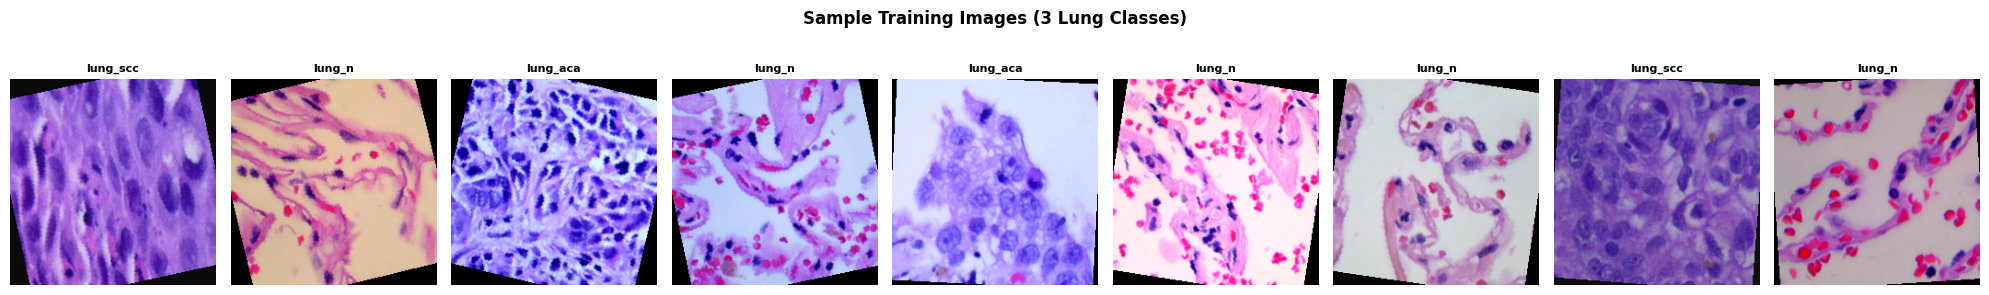

In [15]:
# ── COMPUTE CLASS WEIGHTS ─────────────────────────────────────────────────────
# Counts within the training split
train_labels = [full_dataset.targets[i] for i in train_set.indices]
train_counts = Counter(train_labels)

class_weights = torch.tensor(
    [n_train / (num_classes * train_counts[i]) for i in range(num_classes)],
    dtype=torch.float
).to(device)

print('Class weights (for weighted loss):')
for i, (name, w) in enumerate(zip(class_names, class_weights.cpu())):
    print(f'   [{i}] {name}: {w:.4f}')

# ── DATALOADERS ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_set,      batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set_clean,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set_clean, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print('✅ DataLoaders ready.')

# ── SAMPLE GRID ───────────────────────────────────────────────────────────────
def visualise_batch(loader, class_names, n=9):
    imgs, labels = next(iter(loader))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    imgs = (imgs[:n] * std + mean).clamp(0, 1)
    fig, axes = plt.subplots(1, n, figsize=(20, 3))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i].permute(1,2,0).numpy())
        ax.set_title(class_names[labels[i]], fontsize=8, fontweight='bold')
        ax.axis('off')
    plt.suptitle('Sample Training Images (3 Lung Classes)', fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

visualise_batch(train_loader, class_names)


## 🤖 Step 6 — ViT-B/16 with 3-Class Head

The only architectural change from the binary colon model: `num_classes=3`.

**Head shape comparison:**
- Colon notebook: `Linear(768 → 2)`
- This notebook: `Linear(768 → 3)`

Everything else (patch embedding, transformer blocks, CLS token) is identical.

### Optional: Backbone Freezing
Set `FREEZE_BACKBONE = True` in Step 3 if your dataset is small. This trains only the last 4 blocks + head (~20M params instead of 86M), reducing overfitting on small datasets.


In [16]:
# ── LOAD ViT-B/16 ─────────────────────────────────────────────────────────────
model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,          # ImageNet-1k pretrained weights
    num_classes=NUM_CLASSES   # replace final head: 1000 → 3
)

if FREEZE_BACKBONE:
    unfreeze = ['blocks.8', 'blocks.9', 'blocks.10', 'blocks.11', 'head', 'norm']
    for name, param in model.named_parameters():
        param.requires_grad = any(kw in name for kw in unfreeze)
    print('🔒 Backbone frozen — training last 4 blocks + head only.')

model = model.to(device)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Model   : ViT-Base/16 (ImageNet pretrained)')
print(f'Head    : {model.head}')
print(f'Total params     : {total_p:,}')
print(f'Trainable params : {trainable_p:,}')
print('✅ Model ready.')


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model   : ViT-Base/16 (ImageNet pretrained)
Head    : Linear(in_features=768, out_features=3, bias=True)
Total params     : 85,800,963
Trainable params : 85,800,963
✅ Model ready.


## ⚙️ Step 7 — Weighted Loss, AdamW & Cosine Scheduler

| Component | Setting | Notes |
|---|---|---|
| Loss | `CrossEntropyLoss(weight=class_weights)` | Compensates for class imbalance |
| Optimizer | `AdamW(lr=2e-4, wd=1e-4)` | Best for Transformers |
| Scheduler | `CosineAnnealingLR(T_max=15)` | Smooth LR decay |

The `weight` argument in `CrossEntropyLoss` multiplies the per-sample loss by the class weight before averaging. Classes with fewer samples get higher weights → the model is penalised more for misclassifying them.


In [17]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print('✅ Loss / Optimizer / Scheduler configured.')
print(f'   Loss      : CrossEntropyLoss (weighted)')
print(f'   Optimizer : AdamW  lr={LR}  wd={WEIGHT_DECAY}')
print(f'   Scheduler : CosineAnnealingLR  T_max={NUM_EPOCHS}')


✅ Loss / Optimizer / Scheduler configured.
   Loss      : CrossEntropyLoss (weighted)
   Optimizer : AdamW  lr=0.0002  wd=0.0001
   Scheduler : CosineAnnealingLR  T_max=15


## 🏋️ Step 8 — Training Loop with Best-Model Checkpointing

Identical structure to the colon notebook. The best model (highest val accuracy) is saved automatically.

**Note on the 3-class setting**: Accuracy is a less informative metric when classes are imbalanced. Check the per-class F1 scores in Step 10 for a complete picture.


In [19]:
import torch
import time

# ── UPDATED TRAINING FUNCTION WITH PROGRESS PRINTS ────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    # Print progress 5 times per epoch so you know it's not stuck
    batch_interval = max(1, len(loader) // 5)

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

        # Print status update
        if (batch_idx + 1) % batch_interval == 0:
            print(f"    Batch {batch_idx+1}/{len(loader)} | Loss: {loss.item():.4f}")

    return running_loss / total, correct / total

# ── UPDATED EVALUATE FUNCTION ────────────────────────────────────────────────────
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    # Simple indicator that evaluation is happening
    print("    Evaluating...", end="", flush=True)

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)

    print(" Done.", flush=True)
    return running_loss / total, correct / total

# ── TRAINING LOOP ────────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc    = 0.0
best_model_path = 'best_lung_vit.pth'

print(f'Training ViT-B/16 for {NUM_EPOCHS} epochs on {device}')
print('='*75)
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"Time":>6}')
print('-'*75)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start_time = time.time() # Start timer

    # Train
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # Evaluate
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)

    # Scheduler step
    scheduler.step()

    # Save history
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    # Checkpointing
    saved = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_model_path)
        saved = '  ✅ saved'

    # Calculate duration
    epoch_time = time.time() - epoch_start_time

    # Print results
    print(f'{epoch:>5d} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | '
          f'{vl_loss:>8.4f} | {vl_acc*100:>6.2f}% | {epoch_time:>5.1f}s{saved}')

print('='*75)
print(f'Best Validation Accuracy : {best_val_acc*100:.2f}%')

Training ViT-B/16 for 15 epochs on cuda
Epoch | Train Loss | Train Acc | Val Loss | Val Acc |   Time
---------------------------------------------------------------------------


KeyboardInterrupt: 

## 📈 Step 9 — Training Curves

In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Lung Cancer ViT (3-Class)', fontsize=14, fontweight='bold')

ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train', linewidth=2)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Validation', linewidth=2)
ax1.set_title('Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train', linewidth=2)
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Validation', linewidth=2)
ax2.set_title('Accuracy per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')


## 🧪 Step 10 — Test Evaluation & Per-Class Metrics

For 3-class problems, check **macro-averaged F1** (average F1 across all classes, equal weight regardless of support). This is a fairer metric than accuracy when one class is harder to classify.


In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(device)
        out    = model(imgs)
        probs  = torch.softmax(out, dim=1).cpu()
        preds  = probs.argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = (all_preds == all_labels).mean()
print('='*60)
print(f'  Test Set Accuracy : {test_acc*100:.2f}%')
print('='*60)
print()
print('Detailed Classification Report (per class):')
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


## 📊 Step 11 — Confusion Matrix (3×3)

A 3×3 confusion matrix. The diagonal cells are correct predictions. Off-diagonal cells show which cancer subtypes get confused with each other — clinically important information.


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 13}, ax=ax)
ax.set_title('Confusion Matrix — Test Set (3-Class Lung)', fontweight='bold', fontsize=13, pad=15)
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Per-class accuracy:')
for i, cls in enumerate(class_names):
    acc = cm[i, i] / cm[i].sum()
    print(f'  {cls}: {cm[i,i]}/{cm[i].sum()} = {acc*100:.2f}%')
print('Saved: confusion_matrix.png')


## 🔍 Step 12a — XAI: Improved Attention Rollout

**Improvements over the colon notebook version:**
- Attention is recomputed from Q×K matrices (more accurate than capturing `attn_drop` output)
- Configurable `head_fusion`: mean / min / max
- Configurable `discard_ratio`: zeroes out the lowest attention values (denoises the map)
- Numerically stable normalisation (`+ 1e-8`)


In [ ]:
def compute_attention_rollout(model, img_tensor, device,
                              head_fusion='mean', discard_ratio=0.9):
    """
    Improved Attention Rollout for ViT.

    Args:
        head_fusion   : 'mean' | 'min' | 'max'
        discard_ratio : fraction of lowest attentions to zero-out

    Returns:
        mask       : 2D (H×W) heatmap in [0,1]
        pred_class : int
        confidence : float
    """
    model.eval()
    attention_maps = []

    def hook_fn(module, inp, out):
        B, N, C = inp[0].shape
        qkv = module.qkv(inp[0]).reshape(
            B, N, 3, module.num_heads, C // module.num_heads
        ).permute(2,0,3,1,4)
        q, k, _ = qkv.unbind(0)
        attn = (q @ k.transpose(-2,-1)) * (C // module.num_heads) ** -0.5
        attn = attn.softmax(dim=-1).detach().cpu()
        attention_maps.append(attn)

    hooks = [block.attn.register_forward_hook(hook_fn) for block in model.blocks]

    with torch.no_grad():
        out        = model(img_tensor.unsqueeze(0).to(device))
        pred_class = out.argmax(1).item()
        confidence = torch.softmax(out, dim=1).max().item()

    for h in hooks: h.remove()

    rollout = torch.eye(attention_maps[0].shape[-1])
    for attn in attention_maps:
        if   head_fusion == 'mean': fused = attn.mean(1)[0]
        elif head_fusion == 'min':  fused = attn.min(1).values[0]
        else:                       fused = attn.max(1).values[0]

        thresh = torch.quantile(fused.view(-1), discard_ratio)
        fused[fused < thresh] = 0
        fused = fused + torch.eye(fused.shape[0])
        fused /= fused.sum(dim=-1, keepdim=True)
        rollout = fused @ rollout

    mask = rollout[0, 1:]
    gs   = int(mask.shape[0] ** 0.5)
    mask = mask.reshape(gs, gs).numpy()
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    return mask, pred_class, confidence

print('✅ compute_attention_rollout defined.')


## 🔍 Step 12b — XAI: Grad-CAM for ViT

### What is Grad-CAM?
Gradient-weighted Class Activation Mapping. Key idea:
1. Forward pass → save activations from the **last transformer block**
2. Backward pass → compute gradients of the **target class score** w.r.t. those activations
3. Global-average-pool the gradients → importance weights per activation channel
4. Weighted sum of activations → apply ReLU → reshape 14×14 → upsample to 224×224

**Why Grad-CAM over Attention Rollout?**
- Attention Rollout is **class-agnostic**: the same map regardless of the predicted class
- Grad-CAM is **class-discriminative**: shows what the model specifically attends to *for the predicted class*

Use both together for the most complete explanation.


In [ ]:
class ViTGradCAM:
    """
    Grad-CAM adapted for Vision Transformers.

    Usage:
        gradcam = ViTGradCAM(model)
        cam, pred_class, confidence = gradcam.generate(img_tensor, device)
        gradcam.remove_hooks()    # always clean up after use
    """

    def __init__(self, model, target_layer=None):
        self.model       = model
        self.activations = None
        self.gradients   = None

        layer = target_layer if target_layer else model.blocks[-1]
        self._fwd = layer.register_forward_hook(self._save_act)
        self._bwd = layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, inp, out):
        self.activations = out.detach()        # (B, N_tokens, D)

    def _save_grad(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()  # (B, N_tokens, D)

    def generate(self, img_tensor, device, class_idx=None):
        """
        Generate a Grad-CAM heatmap for a single image.

        Returns:
            cam        : (IMG_SIZE, IMG_SIZE) array in [0,1]
            pred_class : int
            confidence : float
        """
        self.model.eval()
        img_t = img_tensor.unsqueeze(0).to(device)
        img_t.requires_grad_(True)

        output     = self.model(img_t)
        pred_class = output.argmax(1).item()
        confidence = torch.softmax(output, dim=1).max().item()

        target = class_idx if class_idx is not None else pred_class
        self.model.zero_grad()
        output[0, target].backward()

        # Pool gradients over embedding dimension → weights per patch
        weights     = self.gradients[0, 1:].mean(dim=-1)          # (N_patches,)
        activations = self.activations[0, 1:]                     # (N_patches, D)

        cam = F.relu((weights.unsqueeze(-1) * activations).sum(-1))  # (N_patches,)
        gs  = int(cam.shape[0] ** 0.5)                               # 14
        cam = cam.reshape(gs, gs).cpu().detach().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = np.array(
            Image.fromarray((cam * 255).astype(np.uint8)).resize(
                (IMG_SIZE, IMG_SIZE), Image.BILINEAR
            )
        ) / 255.0

        return cam, pred_class, confidence

    def remove_hooks(self):
        self._fwd.remove()
        self._bwd.remove()

print('✅ ViTGradCAM class defined.')


## 🔍 Step 12c — Side-by-Side XAI Comparison

For each sample: **Original | Attention Rollout | Grad-CAM**

This comparison reveals:
- Whether both methods agree on the salient region
- Whether the model focuses on tissue structure (good) or image artifacts (bad)
- Misclassified samples often have diffuse / incorrect attention patterns


In [ ]:
def show_xai_comparison(model, dataset, class_names, device, num_samples=4):
    """
    Display Original | Attention Rollout | Grad-CAM for num_samples images.
    """
    gradcam = ViTGradCAM(model)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(13, num_samples * 4.2))
    fig.suptitle('XAI Comparison: Attention Rollout vs Grad-CAM',
                 fontsize=14, fontweight='bold')

    for col, title in zip(range(3), ['Original Image', 'Attention Rollout', 'Grad-CAM']):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=10)

    for row, idx in enumerate(indices):
        img_tensor, true_label = dataset[idx]
        img_np = np.clip(img_tensor.permute(1,2,0).numpy() * std + mean, 0, 1)

        # Attention Rollout
        ar_mask, pred_ar, conf_ar = compute_attention_rollout(model, img_tensor, device)
        ar_up = np.array(
            Image.fromarray((ar_mask*255).astype(np.uint8)).resize(
                (IMG_SIZE, IMG_SIZE), Image.BILINEAR
            )
        ) / 255.0

        # Grad-CAM
        gc_mask, pred_gc, conf_gc = gradcam.generate(img_tensor, device)

        correct = pred_gc == true_label
        color   = 'green' if correct else 'red'
        status  = '✅' if correct else '❌'

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_ylabel(f'True: {class_names[true_label]}', fontsize=9, fontweight='bold')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(img_np)
        axes[row, 1].imshow(ar_up, alpha=0.55, cmap='jet')
        axes[row, 1].set_title(
            f'Pred: {class_names[pred_ar]} ({conf_ar*100:.1f}%)',
            fontsize=9, color=color
        )
        axes[row, 1].axis('off')

        axes[row, 2].imshow(img_np)
        axes[row, 2].imshow(gc_mask, alpha=0.55, cmap='jet')
        axes[row, 2].set_title(
            f'{status} {class_names[pred_gc]} ({conf_gc*100:.1f}%)',
            fontsize=9, color=color
        )
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.savefig('xai_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    gradcam.remove_hooks()
    print('Saved: xai_comparison.png')


show_xai_comparison(model, test_set_clean, class_names, device, num_samples=4)


## 🏗️ Step 13 — Multi-Modal Fusion Architecture (Blueprint)

This blueprint shows how to extend the single-image ViT classifier to a **multi-modal model** that combines:
- Histopathology images (ViT encoder)
- Radiology scans / CT / X-Ray (smaller ViT or CNN encoder)
- Clinical metadata — age, smoking history, stage, etc. (MLP encoder)

All three branches are concatenated and fed to a shared classification head.

```
Histopathology (224×224) ──► ViT-B/16 (features=768)  ──┐
                                                          ├──► Fusion MLP ──► 3 classes
CT / X-Ray (224×224)     ──► ViT-S/16 (features=384)  ──┤
                                                          │
Clinical Metadata (8 dim)──► MLP Encoder (128 dim)    ──┘
```


In [ ]:
class MultiModalCancerClassifier(nn.Module):
    """
    Multi-modal fusion model for cancer classification.

    Inputs:
        histo_img     : (B, 3, 224, 224) — histopathology patch
        radio_img     : (B, 3, 224, 224) — radiology image (CT / X-Ray)
        clinical_meta : (B, meta_dim)    — tabular clinical features

    Output:
        logits : (B, num_classes)
    """

    def __init__(self, num_classes=3, meta_dim=8, fusion_dim=512, dropout=0.3):
        super().__init__()

        # Histopathology encoder: full ViT-B/16 (768-dim features)
        self.histo_enc = timm.create_model(
            'vit_base_patch16_224', pretrained=True, num_classes=0
        )

        # Radiology encoder: lighter ViT-S/16 (384-dim features)
        self.radio_enc = timm.create_model(
            'vit_small_patch16_224', pretrained=True, num_classes=0
        )

        # Clinical metadata encoder: two-layer MLP
        self.meta_enc = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Linear(64, 128),
            nn.GELU(),
        )

        # Fusion head: concatenate all modality features, then classify
        total_dim = 768 + 384 + 128   # 1280
        self.fusion = nn.Sequential(
            nn.Linear(total_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim // 2, num_classes)
        )

    def forward(self, histo_img, radio_img, clinical_meta):
        f_histo = self.histo_enc(histo_img)      # (B, 768)
        f_radio = self.radio_enc(radio_img)      # (B, 384)
        f_meta  = self.meta_enc(clinical_meta)   # (B, 128)
        fused   = torch.cat([f_histo, f_radio, f_meta], dim=1)
        return self.fusion(fused)


# ── Architecture verification ──────────────────────────────────────────────────
print('MultiModal Cancer Classifier — Shape Verification')
mm_model   = MultiModalCancerClassifier(num_classes=3, meta_dim=8)
B          = 2
dummy_out  = mm_model(torch.randn(B,3,224,224), torch.randn(B,3,224,224), torch.randn(B,8))
print(f'  Output shape : {dummy_out.shape}  (expected: [{B}, 3])')
print(f'  Total params : {sum(p.numel() for p in mm_model.parameters()):,}')
print()
print('Clinical metadata feature guide (meta_dim=8):')
for i, desc in enumerate(['age (normalised)', 'sex (0/1)', 'smoking_pack_years',
                           'tumor_size_cm', 'stage (0-3)',
                           'lymph_node_involvement (0/1)', 'FEV1_ratio', 'CEA_level']):
    print(f'   [{i}] {desc}')


## 🔄 Step 14 — Multi-Organ Extension

The pipeline is designed to be organ-agnostic. To add a new organ, just register it in `MULTI_ORGAN_CONFIG` and call `build_model_for_organ()`. The DataLoader, training loop, and XAI code remain unchanged.


In [ ]:
MULTI_ORGAN_CONFIG = {
    'lung': {
        'classes'    : ['lung_n', 'lung_aca', 'lung_scc'],
        'num_classes': 3,
        'data_dir'   : '/content/drive/MyDrive/lung_dataset',
    },
    'colon': {
        'classes'    : ['colon_aca', 'colon_n'],
        'num_classes': 2,
        'data_dir'   : '/content/drive/MyDrive/colon_dataset',
    },
    'breast': {
        'classes'    : ['breast_benign', 'breast_malignant'],
        'num_classes': 2,
        'data_dir'   : '/content/drive/MyDrive/breast_dataset',
    },
    # ── To add a new organ ────────────────────────────────────────
    # 'prostate': {
    #     'classes'    : ['prostate_benign', 'prostate_malignant'],
    #     'num_classes': 2,
    #     'data_dir'   : '/content/drive/MyDrive/prostate_dataset',
    # },
}

def build_model_for_organ(organ_name, config=MULTI_ORGAN_CONFIG):
    """Instantiate a pretrained ViT-B/16 configured for the specified organ."""
    cfg = config[organ_name]
    m   = timm.create_model(
        'vit_base_patch16_224', pretrained=True, num_classes=cfg['num_classes']
    )
    print(f'Model for [{organ_name}]')
    print(f'  Classes : {cfg["classes"]}')
    print(f'  Head    : {m.head}')
    return m, cfg['classes']

# Example usage (uncomment to use):
# lung_model,   lung_classes   = build_model_for_organ('lung')
# colon_model,  colon_classes  = build_model_for_organ('colon')
# breast_model, breast_classes = build_model_for_organ('breast')

print('Available organs:', list(MULTI_ORGAN_CONFIG.keys()))
print('✅ Call build_model_for_organ(organ_name) to get a ready-to-train model.')


## 💾 Step 15 — Save Model & Download Results

In [ ]:
checkpoint = {
    'model_state_dict' : model.state_dict(),
    'class_names'      : class_names,
    'num_classes'      : NUM_CLASSES,
    'best_val_accuracy': round(best_val_acc, 4),
    'test_accuracy'    : round(test_acc, 4),
    'config': {
        'model'       : 'vit_base_patch16_224',
        'img_size'    : IMG_SIZE,
        'batch_size'  : BATCH_SIZE,
        'num_epochs'  : NUM_EPOCHS,
        'lr'          : LR,
        'weight_decay': WEIGHT_DECAY,
        'task'        : 'lung_3class_classification'
    }
}
torch.save(checkpoint, 'lung_cancer_vit_final.pth')
print('✅ Checkpoint saved: lung_cancer_vit_final.pth')

metrics = {
    'best_val_accuracy': round(best_val_acc * 100, 2),
    'test_accuracy'    : round(test_acc * 100, 2),
    'class_names'      : class_names,
}
with open('metrics_lung.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('✅ Metrics saved: metrics_lung.json')

from google.colab import files
for fname in ['lung_cancer_vit_final.pth', 'training_curves.png',
              'confusion_matrix.png', 'xai_comparison.png', 'metrics_lung.json']:
    if os.path.exists(fname):
        files.download(fname)
        print(f'  Downloaded: {fname}')


## 🔮 Step 16 — Single-Image Inference with XAI

Upload any lung histopathology image and receive:
- The predicted class and confidence
- A bar chart of all class probabilities
- A Grad-CAM heatmap showing what the model focused on


In [ ]:
def predict_with_xai(model, image_path, class_names, device, img_size=224):
    """
    Full inference pipeline for a single image: prediction + Grad-CAM visualisation.
    """
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    pil_img    = Image.open(image_path).convert('RGB')
    img_tensor = transform(pil_img)

    # Grad-CAM
    gradcam = ViTGradCAM(model)
    cam, pred_class, confidence = gradcam.generate(img_tensor, device)
    gradcam.remove_hooks()

    # All class probabilities
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(
            model(img_tensor.unsqueeze(0).to(device)), dim=1
        )[0].cpu().numpy()

    print(f'\n🔬 Image      : {os.path.basename(image_path)}')
    print(f'🎯 Prediction : {class_names[pred_class]} ({confidence*100:.1f}% confidence)')
    print('\nClass probabilities:')
    for i, name in enumerate(class_names):
        bar = '█' * int(probs[i] * 40)
        print(f'   {name:25s}  {probs[i]*100:5.1f}%  {bar}')

    img_np = np.array(pil_img.resize((img_size, img_size))) / 255.0
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(img_np)
    ax1.set_title('Original Image', fontweight='bold')
    ax1.axis('off')

    ax2.imshow(img_np)
    ax2.imshow(cam, alpha=0.55, cmap='jet')
    ax2.set_title(f'Grad-CAM: {class_names[pred_class]} ({confidence*100:.1f}%)',
                  fontweight='bold')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()


# ── Upload & predict ──────────────────────────────────────────────────────────
from google.colab import files
print('Upload a lung histopathology image (JPEG / PNG):')
uploaded = files.upload()
if uploaded:
    img_path = list(uploaded.keys())[0]
    predict_with_xai(model, img_path, class_names, device)
